# Fraud Detection - Data Mining & Pattern Feature
 
 This notebook applies unsupervised learning and feature selection techniques to explore the dataset.
 Goals:
 1. Unsupervised Clustering (K-Means) to find patterns.
 2. Feature Importance / Selection (Lasso/Tree-based).

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = "../artifacts/raw_insertions.parquet"

In [2]:
print(f"Loading data from {DATA_PATH}...")
df_pl = pl.read_parquet(DATA_PATH)

# Select numerical features for Mining
# We rely on heuristic or schema logic
# Let's grab numeric types
numeric_cols = [col for col, dtype in df_pl.schema.items() if dtype in (pl.Float64, pl.Float32, pl.Int64, pl.Int32) and "id" not in col and "timestamp" not in col]
print(f"Numeric Columns for Mining: {numeric_cols}")

# Logic based on EDA Findings
# 1. Target derivation: fraud_flag is a timestamp
df_pl = df_pl.with_columns(
    pl.col("fraud_flag").is_not_null().alias("is_fraud").cast(pl.Int8)
)
TARGET_COL = "is_fraud"

print(f"Fraud Rate: {df_pl['is_fraud'].mean():.4%}")

# 2. Feature Selection & Coalescence
# We need to combine Rent and Buy fields
# listing.prices.rent.gross vs listing.prices.buy.price
# listing.prices.rent.area vs listing.prices.buy.area

# Note: Check if columns exist first to avoid crash if schema varies slightly
available_cols = df_pl.columns

def get_col(candidates):
    for c in candidates:
        if c in available_cols:
            # Force cast to Float64, errors become null
            return pl.col(c).cast(pl.Float64, strict=False) 
    return pl.lit(0.0) # Fallback

df_pl = df_pl.with_columns([
    # Price
    pl.coalesce([
        get_col(["listing.prices.rent.gross", "listing.prices.rent.net"]),
        get_col(["listing.prices.buy.price"]),
        pl.lit(0)
    ]).fill_null(0).alias("feature_price"),
    
    # Area
    pl.coalesce([
        get_col(["listing.prices.rent.area"]),
        get_col(["listing.prices.buy.area"]),
        get_col(["listing.characteristics.lotSize"]),
        pl.lit(0)
    ]).fill_null(0).alias("feature_area"),
    
    # Rooms
    get_col(["listing.characteristics.numberOfRooms"]).fill_null(0).alias("feature_rooms"),
    
    # Bathrooms
    get_col(["listing.characteristics.numberOfBathrooms"]).fill_null(0).alias("feature_bathrooms")
])

# Select features for Mining
numeric_cols = ["feature_price", "feature_area", "feature_rooms", "feature_bathrooms"]
print(f"Derived Features for Mining: {numeric_cols}")

Loading data from ../artifacts/raw_insertions.parquet...
Numeric Columns for Mining: ['auto_approval_criteria.meta.seonFraudScore', 'bundle.immoScout24UpsellPrice', 'bundle.initialPeriodPrice', 'bundle.initialPrice', 'bundle.oldInitialPrice', 'bundle.period', 'bundle.preselectionAddOnPrice', 'bundle.recurringPeriodPrice', 'bundle.recurringPrice', 'listing.address.geoCoordinates.latitude', 'listing.address.geoCoordinates.longitude', 'listing.autoApprovalCriteria.meta.seonFraudScore', 'listing.characteristics.ceilingHeight', 'listing.characteristics.craneCapacity', 'listing.characteristics.cubage', 'listing.characteristics.distanceHighSchool', 'listing.characteristics.distanceKindergarten', 'listing.characteristics.distanceMotorway', 'listing.characteristics.distancePrimarySchool', 'listing.characteristics.distancePublicTransport', 'listing.characteristics.distanceShop', 'listing.characteristics.elevatorCapacity', 'listing.characteristics.floor', 'listing.characteristics.floorLoad', 'lis

## 1. Preprocessing

In [3]:
# Convert to Pandas for Scikit-Learn (sample if too large)
SAMPLE_SIZE = 100000
if df_pl.height > SAMPLE_SIZE:
    print(f"Sampling {SAMPLE_SIZE} rows for mining...")
    df_sample = df_pl.sample(SAMPLE_SIZE, seed=42).to_pandas()
else:
    df_sample = df_pl.to_pandas()

X = df_sample[numeric_cols]
X = X.fillna(0) # Simple fill
X = X.replace([np.inf, -np.inf], 0) # Handle inf

# Log transform price/area to handle skew
# X["feature_price"] = np.log1p(X["feature_price"])
# X["feature_area"] = np.log1p(X["feature_area"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Sampling 100000 rows for mining...


## 2. K-Means Clustering
Explore if distinct clusters exist (e.g., specific types of fraud vs normal).


Running K-Means...


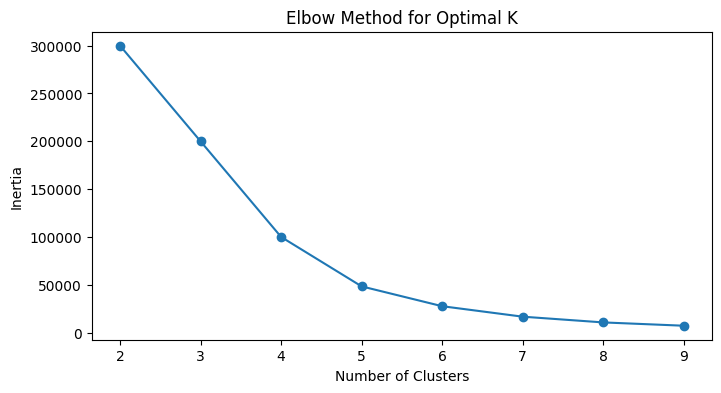


Cluster Distribution:
cluster
0    63467
4    36529
1        2
2        1
3        1
Name: count, dtype: int64

Fraud Rate per Cluster:
cluster
0    0.112925
1    0.000000
2    0.000000
3    0.000000
4    0.029894
Name: is_fraud, dtype: float64


In [5]:
print("\nRunning K-Means...")
errors = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    errors.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, errors, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Pick K=5 roughly
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_sample["cluster"] = clusters

print("\nCluster Distribution:")
print(df_sample["cluster"].value_counts())

# If we have target, check fraud rate per cluster
if TARGET_COL in df_sample.columns:
    print("\nFraud Rate per Cluster:")
    print(df_sample.groupby("cluster")[TARGET_COL].mean())

## 3. Feature Selection (Lasso / Random Forest)
Identify which features drive variance or predictiveness.

In [7]:
if TARGET_COL in df_sample.columns:
    y = df_sample[TARGET_COL].fillna(0) # Careful with target fill
    
    print("\nFeature Importance (Random Forest):")
    rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    rf.fit(X_scaled, y)
    
    importances = pd.DataFrame({
        "feature": numeric_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)
    
    print(importances.head(10))
    
    print("\nLasso Coefficients (L1 Regularization):")
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_scaled, y)
    
    lasso_res = pd.DataFrame({
        "feature": numeric_cols,
        "coef": lasso.coef_
    })
    print(lasso_res[lasso_res["coef"] != 0])
else:
    print("Target column not available for supervised feature selection.")


Feature Importance (Random Forest):
             feature    importance
2      feature_rooms  8.322890e-01
1       feature_area  9.794303e-02
0      feature_price  6.976797e-02
3  feature_bathrooms  1.243974e-08

Lasso Coefficients (L1 Regularization):
         feature      coef
2  feature_rooms -0.024548
